# EDA — Combining speeches with energy data (RQ1)

**RQ1:** *Among the world's major fossil-fuel economies, how does the frequency of energy-transition mentions in
their UN General Debate speeches correlate with the fossil-fuel share of their primary energy consumption after the
2015 Paris Agreement?*

`04_eda` defined the **major fossil-fuel economies** (the 15 countries in the top quartile of both fossil-fuel
production and fossil-fuel rents, saved as `major_fossil_economies.csv`), but never looked at what those countries
say. This notebook brings the two halves together: the transition-mention counts from `02_preprocessing_advanced`
and the fossil share of each country's primary energy consumption (how fossil-based its energy mix is) from
`03_external_data`.

**Run order:** 01 → 02 → 03 → 04_eda → this notebook → 06.

We measure the relationship at three levels, because each one answers a different question:

1. **Pooled** — every country-year is one observation. Simple, but it mixes up differences *between* countries with
   changes *within* a country over time.
2. **Between countries** — one value per country: do the countries that talk more about the transition have a lower
   fossil share, or a fossil share that falls faster?
3. **Within countries** — does a country talk more in the years in which its fossil share is lower than usual?

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

# One fixed colour per group, used in every chart below
MAJOR_COLOR = '#2a78d6'
OTHER_COLOR = '#eb6834'
INK = '#52514e'

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#c3c2b7',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'axes.titlesize': 11,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'legend.frameon': False,
})

## Step 1 — Load the speech features

We take `transition_mention_count` from the advanced notebook and `WordCount` from the simple one and turn them into
**mentions per 1,000 words**. A long speech naturally contains more mentions of any topic, so raw counts would partly
measure speech length. We scale to 1,000 words only to keep the numbers readable (per single word they would be around
0.0003). `mentions_any` flags whether a speech mentions the transition at all, which is useful because most speeches
don't.

In [2]:
speeches = pd.read_parquet('../datasets/speeches_advanced_clean.parquet')
word_counts = pd.read_parquet('../datasets/speeches_simple_clean.parquet', columns=['WordCount'])

speeches = speeches.join(word_counts, how='left')
speeches = speeches.reset_index().rename(columns={'ISO-alpha3 Code': 'iso3'})
speeches['mentions_per_1k'] = speeches['transition_mention_count'] / speeches['WordCount'] * 1000
speeches['mentions_any'] = speeches['transition_mention_count'] > 0

speeches = speeches[['iso3', 'Year', 'Country or Area', 'WordCount',
                     'transition_mention_count', 'mentions_per_1k', 'mentions_any']]
print(speeches.shape)
speeches[['transition_mention_count', 'mentions_per_1k', 'mentions_any']].describe()

(2128, 7)


,transition_mention_count,mentions_per_1k
count,2128.000000,2128.000000
mean,0.671992,0.334148
std,1.367060,0.680655
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.482975
max,20.000000,7.815553


## Step 2 — Add the major-fossil-economy flag and fossil share

- **`major_fossil_economies.csv`** (from `04_eda`): the flag `major_fossil_economy` marks the 15 countries in the top
  quartile of *both* fossil-fuel production (TWh) and fossil-fuel rents (% of GDP).
- **`fossil_share_pct`** (from `03_external_data`, OWID): the share of a country's primary energy consumption that
  comes from coal, oil and gas, i.e. how fossil-based its energy mix is. OWID only covers 79 countries (it relies on
  the Energy Institute's *Statistical Review of World Energy*), so wherever we compare the major fossil-fuel
  economies with "other countries", that means the other countries **with fossil-share data**, not all UN members.

We inner-join the speeches to fossil share on (iso3, Year), since a country-year needs both values to enter a
correlation, and then check how many years each major fossil-fuel economy has.

In [3]:
flags = pd.read_csv('../datasets/prepared_data/major_fossil_economies.csv')
major_iso3 = set(flags.loc[flags['major_fossil_economy'], 'iso3'])
print(f"{len(major_iso3)} major fossil-fuel economies: {', '.join(sorted(major_iso3))}")

panel = pd.read_csv('../datasets/prepared_data/master_panel_country_year.csv')
fossil_share = panel.loc[panel['Year'] >= 2015, ['iso3', 'Year', 'fossil_share_pct']].dropna()

speeches['major_fossil_economy'] = speeches['iso3'].isin(major_iso3)
combined = speeches.merge(fossil_share, on=['iso3', 'Year'], how='inner')

print(f"{len(combined)} country-years from {combined['iso3'].nunique()} countries")
print(combined.groupby('major_fossil_economy')['iso3'].nunique())

years_per_country = combined[combined['major_fossil_economy']].groupby('iso3')['Year'].agg(['count', 'min', 'max'])
years_per_country[years_per_country['count'] < 11]

15 major fossil-fuel economies: ARE, AUS, BRA, DZA, IDN, IRN, IRQ, KAZ, KWT, MEX, NOR, QAT, RUS, SAU, ZAF
792 country-years from 73 countries
major_fossil_economy
False    58
True     15
Name: iso3, dtype: int64


,count,min,max
iso3,,,
IRQ,3,2017,2019


Every major fossil-fuel economy gave a speech in every year from 2015 to 2025 and has fossil-share data for all 11 years, except
**Iraq**, which OWID only covers for 2017–2019. Iraq stays in the pooled and within-country analysis, but it gets no
fossil-share trend in Step 4, because a trend over 3 years can't be compared with one over 11.

## Step 3 — How much do the major fossil-fuel economies talk about the transition?

Before correlating anything we look at the talk side on its own. This step doesn't need fossil-share data, so it uses
**all** 2,128 speeches since 2015: the 15 major fossil-fuel economies against every other country. We show two views because the
mention rate is zero-inflated: the share of speeches that mention the transition at all, and the average number of
mentions per 1,000 words.

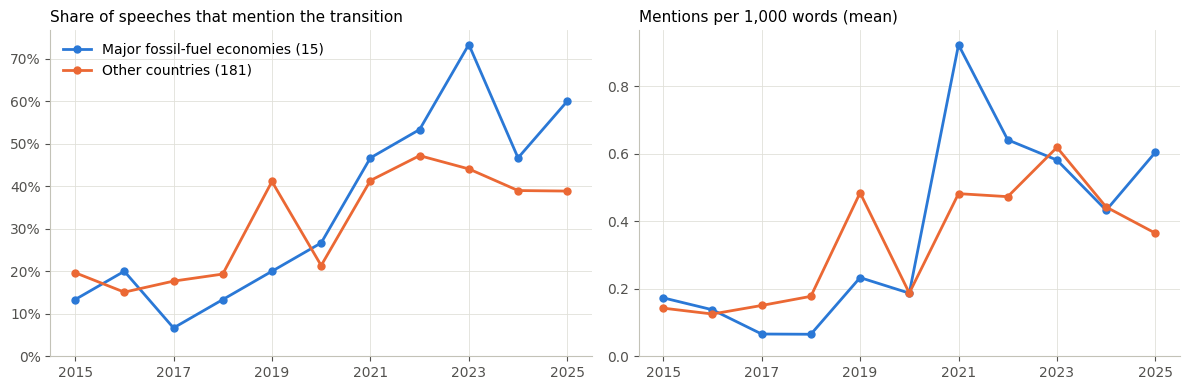

major_fossil_economy,False,True
Year,,
2015,0.20,0.13
2016,0.15,0.20
2017,0.18,0.07
2018,0.19,0.13
2019,0.41,0.20
2020,0.21,0.27
2021,0.41,0.47
2022,0.47,0.53
2023,0.44,0.73


In [4]:
yearly = (speeches.groupby(['Year', 'major_fossil_economy'])
          .agg(share_mentioning=('mentions_any', 'mean'), mentions_per_1k=('mentions_per_1k', 'mean'))
          .reset_index())

n_major = speeches.loc[speeches['major_fossil_economy'], 'iso3'].nunique()
n_other = speeches.loc[~speeches['major_fossil_economy'], 'iso3'].nunique()
groups = [(True, MAJOR_COLOR, f'Major fossil-fuel economies ({n_major})'), (False, OTHER_COLOR, f'Other countries ({n_other})')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
views = [('share_mentioning', 'Share of speeches that mention the transition', 100),
         ('mentions_per_1k', 'Mentions per 1,000 words (mean)', 1)]
for ax, (col, title, scale) in zip(axes, views):
    for is_major, color, label in groups:
        g = yearly[yearly['major_fossil_economy'] == is_major]
        ax.plot(g['Year'], g[col] * scale, color=color, linewidth=2, marker='o', markersize=5, label=label)
    ax.set_title(title, loc='left')
    ax.set_ylim(bottom=0)
    ax.set_xticks(range(2015, 2026, 2))
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v:.0f}%')
axes[0].legend(loc='upper left')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/rq1_talk_over_time.png', dpi=200, bbox_inches='tight')
plt.show()

yearly.pivot(index='Year', columns='major_fossil_economy', values='share_mentioning').round(2)

Until 2018, fewer than one in five speeches mentioned the energy transition in either group. Other countries
jumped first, in 2019 (the year of the UN Climate Action Summit). The major fossil-fuel economies caught up in 2021 (COP26 in
Glasgow) and since then have mentioned the transition in a *larger* share of their speeches than other countries,
reaching 73% in 2023, the year one of the 15, the United Arab Emirates, hosted COP28. With only 15 countries the line for the major fossil-fuel economies is noisy (one speech moves it by almost 7 percentage points), but the direction is clear: on average
the major fossil-fuel economies are not quieter about the transition than the rest of the world. The question is whether that talk
goes together with changes in their energy mix.

## Step 4 — Country profiles of the major fossil-fuel economies

The group average hides big differences between the 15 countries. For each country we put its talk (from all its
speeches since 2015) next to its fossil share at the start and the end of the period, and the **trend** in its fossil
share.

The trend is the slope of a straight line fitted through the country's yearly fossil share, in percentage points per
year (negative means moving away from fossil fuels). We use the slope instead of just "last year minus first year"
because it uses all 11 years, so a single unusual year (such as 2020, when COVID cut energy use) can't dominate it. It
is only computed for countries with at least 5 years of data.

The table covers every country that has both speeches and fossil-share data; the major fossil-fuel economies are shown below, and
the other countries are used as the comparison group in Step 6.

In [5]:
def fossil_trend(group):
    if len(group) < 5:
        return np.nan
    return linregress(group['Year'], group['fossil_share_pct']).slope


trend = fossil_share.groupby('iso3')[['Year', 'fossil_share_pct']].apply(fossil_trend).rename('fossil_trend_pp_per_year')

talk = (speeches.groupby('iso3')
        .agg(country=('Country or Area', 'first'),
             major_fossil_economy=('major_fossil_economy', 'first'),
             speeches=('Year', 'size'),
             total_mentions=('transition_mention_count', 'sum'),
             share_mentioning=('mentions_any', 'mean'),
             mentions_per_1k=('mentions_per_1k', 'mean')))

energy = (fossil_share.sort_values('Year')
          .groupby('iso3')
          .agg(first_year=('Year', 'first'),
               last_year=('Year', 'last'),
               fossil_share_first=('fossil_share_pct', 'first'),
               fossil_share_last=('fossil_share_pct', 'last'),
               fossil_share_mean=('fossil_share_pct', 'mean'))
          .join(trend))

country = talk.join(energy, how='inner')
country['fossil_share_change'] = country['fossil_share_last'] - country['fossil_share_first']
print(country['major_fossil_economy'].value_counts())

major_profile = country[country['major_fossil_economy']].sort_values('mentions_per_1k', ascending=False)
major_profile.drop(columns='major_fossil_economy').round(2)

major_fossil_economy
False    58
True     15
Name: count, dtype: int64


,country,speeches,total_mentions,share_mentioning,mentions_per_1k,first_year,last_year,fossil_share_first,fossil_share_last,fossil_share_mean,fossil_trend_pp_per_year,fossil_share_change
iso3,,,,,,,,,,,,
BRA,Brazil,11,25,0.73,1.10,2015,2025,72.34,62.32,66.78,-0.93,-10.03
AUS,Australia,11,27,0.64,1.03,2015,2025,97.06,92.11,94.92,-0.53,-4.94
NOR,Norway,11,14,0.64,0.73,2015,2025,54.04,46.91,51.30,-0.71,-7.13
KAZ,Kazakhstan,11,15,0.73,0.69,2015,2025,98.48,98.07,98.34,-0.04,-0.41
ARE,United Arab Emirates,11,9,0.64,0.44,2015,2025,99.98,90.47,96.61,-1.13,-9.50
ZAF,South Africa,11,8,0.45,0.38,2015,2025,96.79,95.27,96.03,-0.10,-1.52
IDN,Indonesia,11,4,0.18,0.29,2015,2025,93.63,88.32,88.95,-0.60,-5.31
SAU,Saudi Arabia,11,6,0.27,0.24,2015,2025,100.00,99.41,99.89,-0.04,-0.59
QAT,Qatar,11,5,0.27,0.23,2015,2025,99.94,99.37,99.82,-0.05,-0.56


Talk is very uneven among the major fossil-fuel economies. Brazil, Australia, Norway and Kazakhstan mention the transition most
(0.7–1.1 times per 1,000 words, in 64–73% of their speeches). Russia and Algeria did not mention it once in 11
speeches, and Iran, Mexico and Kuwait only once or twice. Fossil share is just as uneven: Brazil, the UAE, Norway,
Indonesia and Australia lowered theirs by roughly 5–10 percentage points, while Saudi Arabia, Qatar, Kuwait, Iraq and
Algeria ran on more than 99% fossil energy throughout and barely moved.

## Step 5 — Fossil share over time, ordered by how much each country talks

One small panel per major fossil-fuel economy, all on the same y-axis, ordered from the country that talks most about the
transition (top left) to the one that talks least (bottom right). If talk and energy mix go together, the falling
lines should sit in the first rows and the flat lines in the last.

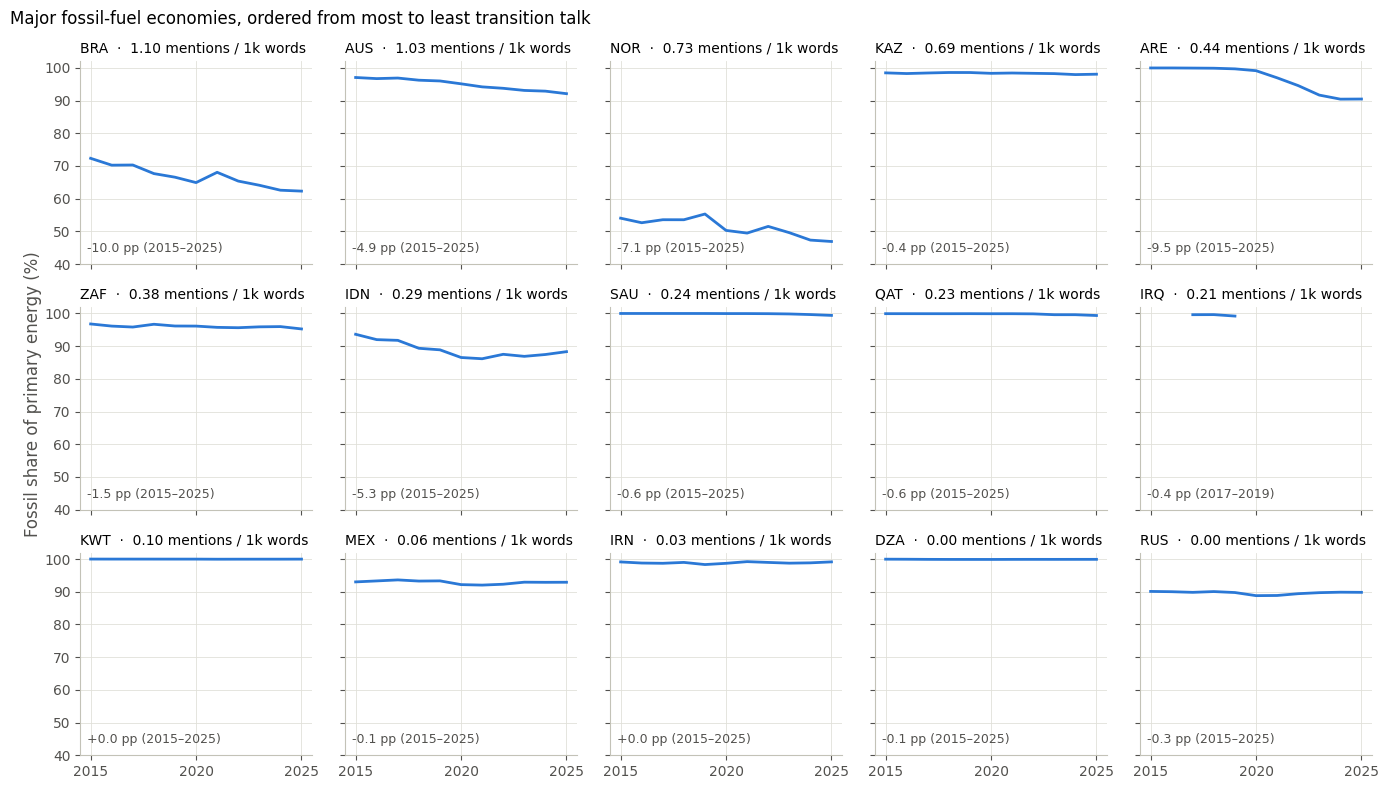

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(14, 8), sharex=True, sharey=True)
for ax, (iso3, row) in zip(axes.flat, major_profile.iterrows()):
    series = fossil_share[fossil_share['iso3'] == iso3]
    ax.plot(series['Year'], series['fossil_share_pct'], color=MAJOR_COLOR, linewidth=2)
    ax.set_title(f"{iso3}  ·  {row['mentions_per_1k']:.2f} mentions / 1k words", loc='left', fontsize=10)
    change = round(row['fossil_share_change'], 1) + 0.0  # + 0.0 turns -0.0 into 0.0
    ax.text(0.03, 0.06, f"{change:+.1f} pp ({row['first_year']:.0f}–{row['last_year']:.0f})",
            transform=ax.transAxes, fontsize=9, color=INK)
axes[0, 0].set_ylim(40, 102)
axes[0, 0].set_xticks([2015, 2020, 2025])
fig.supylabel('Fossil share of primary energy (%)', color=INK)
fig.suptitle('Major fossil-fuel economies, ordered from most to least transition talk', x=0.01, ha='left', fontsize=12)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/rq1_fossil_share_small_multiples.png', dpi=200, bbox_inches='tight')
plt.show()

Four of the five countries in the first row (Brazil, Australia, Norway and the UAE) have clearly falling lines, and
so does Indonesia in the second row. The last row is five flat lines: Kuwait, Mexico, Iran, Algeria and Russia
hardly mention the transition, and their energy mix hardly changed. Kazakhstan is the clearest exception: it talks
about the transition about as much as Norway, but its fossil share stayed at about 98%.

## Step 6 — Correlation between talk and fossil share

We use **Spearman's rank correlation** (ρ) throughout instead of Pearson's. The mention rate is heavily zero-inflated
and skewed (most speeches have no mentions, a few have many), and the between-country comparison has only 14 major fossil-fuel economies. A rank-based correlation isn't pulled around by one extreme value and doesn't assume a straight-line
relationship. ρ runs from −1 to +1. A **negative** ρ here means "more transition talk goes together with a lower, or
faster-falling, fossil share", i.e. words and energy mix point the same way.

Each correlation is computed for the major fossil-fuel economies and, as a reference, for the other countries with fossil-share
data, so we can see whether the major fossil-fuel economies behave differently.

The within-country level needs one extra step. Talk about the transition rose almost everywhere after 2019, and
fossil shares fell slowly almost everywhere, so any two countries' series trend in opposite directions over time even
if they have nothing to do with each other. To remove that, we subtract each country's own average (which removes
permanent differences, such as Norway's hydropower) **and** each year's average (which removes what happened to
everyone at once, such as COVID in 2020 or the general rise in climate talk). What is left answers: *was this country
talking more than usual in a year when its fossil share was lower than usual?* We show the version with only the
country average removed as well, to make the effect of the time trend visible.

In [7]:
results = []


def add_result(level, data, x_col, y_col):
    for is_major, group_name in [(True, 'Major fossil-fuel economies'), (False, 'Other countries')]:
        subset = data[data['major_fossil_economy'] == is_major].dropna(subset=[x_col, y_col])
        rho, p = spearmanr(subset[x_col], subset[y_col])
        results.append({'level': level, 'group': group_name, 'n': len(subset), 'spearman_rho': rho, 'p_value': p})


# Pooled: every country-year is one observation
add_result('Pooled: mentions vs fossil share (country-years)', combined, 'mentions_per_1k', 'fossil_share_pct')

# Between countries: one value per country
add_result('Between: mean mentions vs mean fossil share', country, 'mentions_per_1k', 'fossil_share_mean')
add_result('Between: mean mentions vs fossil share trend', country, 'mentions_per_1k', 'fossil_trend_pp_per_year')

# Within countries: remove each country's average, then each year's average (per group)
within = combined.copy()
for col in ['mentions_per_1k', 'fossil_share_pct']:
    within[col] = within[col] - within.groupby('iso3')[col].transform('mean')
add_result('Within: country averages removed', within, 'mentions_per_1k', 'fossil_share_pct')
for col in ['mentions_per_1k', 'fossil_share_pct']:
    within[col] = within[col] - within.groupby(['major_fossil_economy', 'Year'])[col].transform('mean')
add_result('Within: country and year averages removed', within, 'mentions_per_1k', 'fossil_share_pct')

results_table = pd.DataFrame(results)
results_table.round(3)

,level,group,n,spearman_rho,p_value
0,Pooled: mentions vs fossil share (country-years),Major fossil-fuel economies,157,-0.318,0.000
1,Pooled: mentions vs fossil share (country-years),Other countries,635,-0.072,0.071
2,Between: mean mentions vs mean fossil share,Major fossil-fuel economies,15,-0.479,0.071
3,Between: mean mentions vs mean fossil share,Other countries,58,-0.036,0.788
4,Between: mean mentions vs fossil share trend,Major fossil-fuel economies,14,-0.757,0.002
5,Between: mean mentions vs fossil share trend,Other countries,58,-0.007,0.960
6,Within: country averages removed,Major fossil-fuel economies,157,-0.250,0.002
7,Within: country averages removed,Other countries,635,-0.184,0.000
8,Within: country and year averages removed,Major fossil-fuel economies,157,-0.110,0.170
9,Within: country and year averages removed,Other countries,635,0.054,0.171


The between-country trend is the clearest relationship in the table, so we plot it: one dot per country, major fossil-fuel economies labelled.

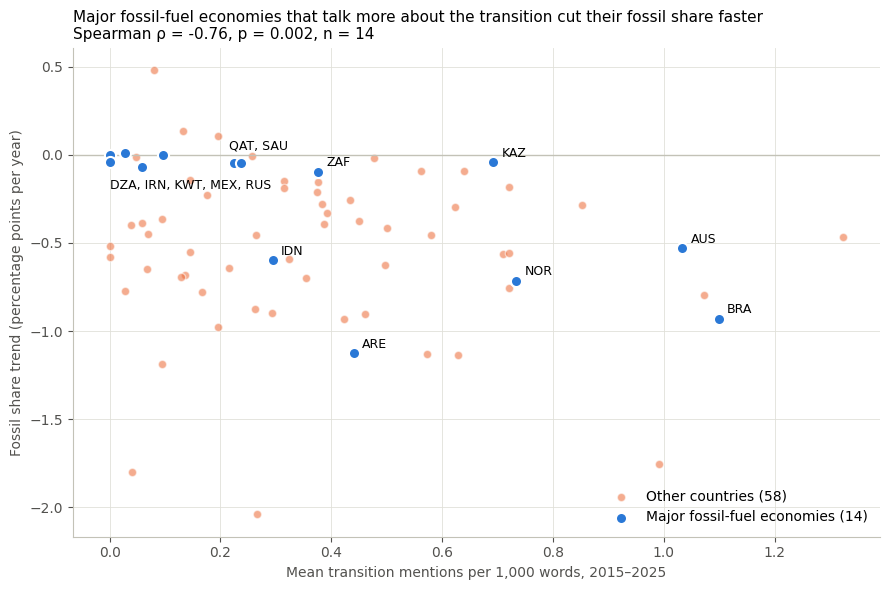

In [8]:
has_trend = country.dropna(subset=['fossil_trend_pp_per_year'])
majors = has_trend[has_trend['major_fossil_economy']]
others = has_trend[~has_trend['major_fossil_economy']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0, color='#c3c2b7', linewidth=1)
ax.scatter(others['mentions_per_1k'], others['fossil_trend_pp_per_year'], s=36, color=OTHER_COLOR, alpha=0.55,
           edgecolor='white', linewidth=1, label=f'Other countries ({len(others)})')
ax.scatter(majors['mentions_per_1k'], majors['fossil_trend_pp_per_year'], s=64, color=MAJOR_COLOR,
           edgecolor='white', linewidth=1.5, label=f'Major fossil-fuel economies ({len(majors)})', zorder=3)

# Dots that (almost) sit on top of each other share one label, e.g. the five producers that hardly
# ever mention the transition, all near (0, 0). That label goes underneath its dots; any other shared
# label goes above, so the two don't run into each other.
clusters = []
for iso3, row in majors.sort_values('mentions_per_1k').iterrows():
    x, y = row['mentions_per_1k'], row['fossil_trend_pp_per_year']
    if clusters and x - clusters[-1]['x'] < 0.13 and abs(y - clusters[-1]['y']) < 0.1:
        clusters[-1]['names'].append(iso3)
        clusters[-1]['y_min'] = min(clusters[-1]['y_min'], y)
    else:
        clusters.append({'x': x, 'y': y, 'y_min': y, 'names': [iso3]})
for c in clusters:
    if len(c['names']) == 1:
        ax.annotate(c['names'][0], (c['x'], c['y']), xytext=(6, 4), textcoords='offset points', fontsize=9)
    elif c['x'] < 0.1:
        ax.annotate(', '.join(sorted(c['names'])), (c['x'], c['y_min']), xytext=(0, -16),
                    textcoords='offset points', fontsize=9)
    else:
        ax.annotate(', '.join(sorted(c['names'])), (c['x'], c['y']), xytext=(-4, 10),
                    textcoords='offset points', fontsize=9)

rho, p = spearmanr(majors['mentions_per_1k'], majors['fossil_trend_pp_per_year'])
ax.set_title(f'Major fossil-fuel economies that talk more about the transition cut their fossil share faster\n'
             f'Spearman ρ = {rho:.2f}, p = {p:.3f}, n = {len(majors)}', loc='left', fontsize=11)
ax.set_xlabel('Mean transition mentions per 1,000 words, 2015–2025')
ax.set_ylabel('Fossil share trend (percentage points per year)')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/rq1_talk_vs_fossil_trend.png', dpi=200, bbox_inches='tight')
plt.show()

**What the table shows:**

- **Pooled** (ρ = −0.32 for the major fossil-fuel economies): country-years with more talk have a lower fossil share. But this mixes
  two different things, which the next rows separate.
- **Between countries, level** (ρ = −0.48, p = 0.07): major fossil-fuel economies that talk more tend to have a lower average
  fossil share, but with 15 countries this is not significant at the 5% level.
- **Between countries, trend** (ρ = −0.76, p = 0.002): the strongest result. The major fossil-fuel economies that talk more about
  the transition are the ones whose fossil share fell fastest after 2015. In the scatter plot the silent producers
  sit at zero on both axes (top left), while Brazil, Norway, Australia and the UAE both talk and cut.
- **Other countries** show no relationship at the between-country level (ρ ≈ 0): among them, how much a country
  talks about the transition says nothing about its energy mix. The link is specific to the major fossil-fuel economies.
- **Within countries:** with only the country averages removed, ρ is −0.25 (major fossil-fuel economies) and −0.18 (others), both
  significant. Once the year averages are removed too, it drops to −0.11 and +0.05, neither significant. So that
  apparent within-country link was the shared time trend (more climate talk and slightly lower fossil shares
  everywhere in later years), not countries talking more in the particular years their own fossil share fell.

## Step 7 — Robustness of the between-country result

With only 14 countries, one country could be carrying the whole correlation, so we run two checks:

1. **Leave one out:** recompute ρ 14 times, each time without one of the countries. If ρ stays in a narrow range, no
   single country drives the result.
2. **Drop the countries at a fossil "ceiling":** the Gulf producers run on 99%+ fossil energy, talk little, and their
   share can't move much in either direction. If the correlation only came from that group sitting at the corner of
   the chart, it would disappear once they are removed.

In [9]:
key = majors[['mentions_per_1k', 'fossil_trend_pp_per_year', 'fossil_share_mean']]

loo_rhos = pd.Series({iso3: spearmanr(key.drop(iso3)['mentions_per_1k'],
                                      key.drop(iso3)['fossil_trend_pp_per_year']).statistic
                      for iso3 in key.index})
print(f"All {len(key)} major fossil-fuel economies: rho = {rho:.2f}, p = {p:.3f}")
print(f"Leave one out: rho between {loo_rhos.min():.2f} (without {loo_rhos.idxmin()}) "
      f"and {loo_rhos.max():.2f} (without {loo_rhos.idxmax()})")

below_ceiling = key[key['fossil_share_mean'] < 99]
rho_bc, p_bc = spearmanr(below_ceiling['mentions_per_1k'], below_ceiling['fossil_trend_pp_per_year'])
dropped = sorted(set(key.index) - set(below_ceiling.index))
print(f"Without the countries at >= 99% fossil share ({', '.join(dropped)}): "
      f"rho = {rho_bc:.2f}, p = {p_bc:.3f}, n = {len(below_ceiling)}")

All 14 major fossil-fuel economies: rho = -0.76, p = 0.002
Leave one out: rho between -0.84 (without KAZ) and -0.72 (without BRA)
Without the countries at >= 99% fossil share (DZA, KWT, QAT, SAU): rho = -0.67, p = 0.033, n = 10


The result is not driven by one country: leaving any single country out keeps ρ between −0.84 and −0.72. It is
strongest without Kazakhstan (the country that talks a lot without cutting) and weakest without Brazil. It also
doesn't come only from the countries stuck near 100% fossil energy: without Algeria, Kuwait, Qatar and Saudi Arabia,
ρ is still −0.67 (p = 0.03, n = 10).

## Step 8 — Answer to RQ1

**Among the major fossil-fuel economies, the countries that talk more about the energy transition at the UN are the
ones whose fossil share of primary energy fell faster after 2015** (Spearman ρ = −0.76, p = 0.002, n = 14). This holds when
any single country is left out and when the countries at the ~100% fossil ceiling are removed. Countries that talk
more also tend to have a lower fossil share overall (ρ = −0.48), but that is not significant (p = 0.07).

Two things this does **not** show:

- **No year-to-year link.** Countries don't talk more in the particular years their fossil share falls. Once shared
  time trends are removed, the within-country correlation disappears (ρ = −0.11, p = 0.17). The relationship is about
  *which* countries transition, not *when*.
- **No link for other countries.** Among the 58 other countries with energy data, talk and fossil share are unrelated
  (ρ ≈ 0).

So at the country level the major fossil-fuel economies largely *practice what they preach*: the ones that talk about the
transition (Brazil, Norway, Australia, the UAE) are also changing their energy mix, and the ones that stay silent
(Russia, Algeria, Iran, Kuwait) haven't changed theirs. Kazakhstan is the main exception: a lot of talk, no change.

**Caveats for the report**

- **Correlation, not causation, and a small sample.** With 14 countries, the direction could just as well run the
  other way: countries whose energy mix is already changing have progress to report, so they may *preach what they
  practice*.
- **Consumption is not production.** Fossil share measures the domestic energy mix. A country can make its own energy
  use greener while still producing and exporting fossil fuels (Norway and Australia are both large exporters). RQ2
  looks at production directly.
- **Narrow keyword list.** Mentions come from the energy-transition keyword list in notebook 02. Broader climate talk
  ("climate change", "emissions", "Paris Agreement") is not counted.
- **Comparison group.** "Other countries" means the 58 other countries that OWID covers, mostly large energy producers
  and consumers, not all UN members.
- **Iraq** only has fossil-share data for 2017–2019, so it has no trend and is left out of the trend correlation.

## Step 9 — Save

The country table (talk and fossil-share summary per country) and the correlation table are saved so the report can
use them without re-running this notebook. The three figures were already saved to `figures/`.

In [10]:
country.to_csv('../datasets/prepared_data/rq1_country_summary.csv')
results_table.to_csv('../datasets/prepared_data/rq1_correlations.csv', index=False)
print(country.shape, results_table.shape)

(73, 13) (10, 5)
